
# Week 8 · Day 3 — CAPSTONE ASSIGNMENT
# Your Portfolio Project 🏆

**This is the final project of the course.** It ties everything together and becomes the centerpiece of your GitHub portfolio.

You'll run a **complete data project** on a dataset of **your choice**, following the 7 stages from class:

> **Problem → Load → Clean → Explore → Visualize → Model → Result**

### Choosing your dataset
- **Best:** pick a dataset that interests *you* (Kaggle, `seaborn.load_dataset(...)`, or a CSV you like). It must be a **classification** problem — predicting a category.
- **Safety net:** if you're short on time, use the provided **Iris** dataset in the starter cell below. Swapping in your own dataset later is easy.

### This is portfolio quality
- English only, clean cells, clear markdown between steps.
- A recruiter or professor may read this. Make it something you're proud of.

---
### Marks: 20 total
| Section | Marks |
|--|--|
| Problem statement (markdown) | 2 |
| Load & inspect | 2 |
| Clean the data | 3 |
| Explore + at least one visualization | 3 |
| Train a model (5-step recipe) | 4 |
| Accuracy + confusion matrix | 3 |
| Result write-up (markdown) | 3 |

## Stage 1 — Problem statement (2 marks)

Double-click and write, in plain English:
- What dataset are you using?
- What are you trying to **predict** (the target)?
- Which columns will you use as **clues** (features)?

*Your problem statement:*

Dataset: Titanic dataset (built-in seaborn dataset, containing passenger details from the Titanic voyage).
Target: I am trying to predict "survived" — whether a passenger survived or not.
Features (clues): pclass, sex, age, and fare will be used to predict survival.
___


## Stage 2 — Load & inspect (2 marks)

The cell below loads the **fallback Iris** dataset. **To use your own dataset, replace this cell** with your own load (e.g. `pd.read_csv("data/your_file.csv")` or another `sns.load_dataset(...)`).

Then print the shape and missing-value counts.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# ---- FALLBACK DATASET (replace with your own if you like) ----
df = sns.load_dataset("titanic")
# --------------------------------------------------------------

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Print the shape and the missing values per column
# YOUR CODE HERE
print(df.shape)
print(df.isnull().sum())

(891, 15)
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Stage 3 — Clean the data (3 marks)

Work on a `.copy()`. Handle missing values (fill or drop, and say which) and turn any text columns you need into numbers. If your dataset is already clean (like Iris), briefly note that in a comment.

In [5]:

# YOUR CODE HERE
df_clean = df.copy()

# Iris dataset is already clean — no missing values, and all feature
# columns (sepal_length, sepal_width, petal_length, petal_width) are
# already numeric. The only text column is "species" (the target),
# which sklearn's classifiers can handle directly as string labels,
# so no encoding is needed here.

print(df_clean.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


## Stage 4 — Explore + visualize (3 marks)

Show the count of each target category, and draw **at least one** plot that explores the data (scatter, countplot, histogram — your choice). Add a title.

age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
pclass
3    491
1    216
2    184
Name: count, dtype: int64


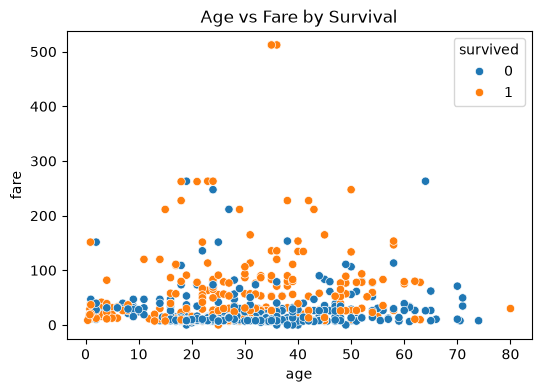

In [9]:
# YOUR CODE HERE
print(df_clean["age"].value_counts())
print(df_clean["pclass"].value_counts())

plt.figure(figsize=(6,4))
sns.scatterplot(data=df_clean, x="age", y="fare", hue="survived")
plt.title("Age vs Fare by Survival")
plt.show()



## Stage 5 — Train a model (4 marks)

Follow the 5-step recipe:
1. Set `X` (features) and `y` (target)
2. `train_test_split` (20% test, `random_state=42`)
3. Create a `KNeighborsClassifier`
4. `.fit()` on the training data
5. `.predict()` on the test set

In [17]:
# YOUR CODE HERE
X = df_clean[["pclass", "age", "fare"]].copy()
X["age"] = X["age"].fillna(X["age"].median())
y = df_clean["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = KNeighborsClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## Stage 6 — Accuracy + confusion matrix (3 marks)

Print the accuracy as a percentage, then draw the confusion matrix as a heatmap.

Accuracy: 64.25%


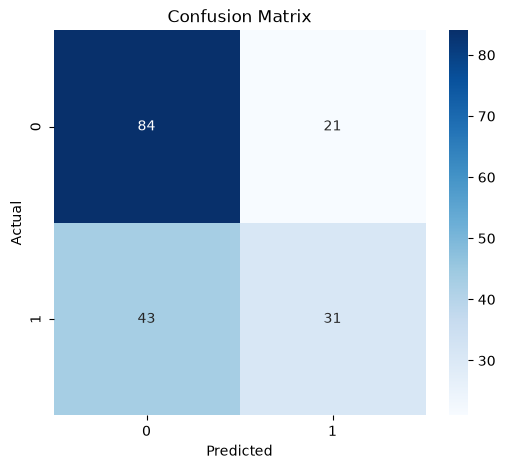

In [18]:
# YOUR CODE HERE
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()



## Stage 7 — Result write-up (3 marks) ✍️

Double-click and write a short report (5–7 sentences) in the **problem → approach → result** shape:
- What question did you ask?
- What did you do (clean, features, model)?
- What accuracy did you get, and what does the confusion matrix show about the mistakes?
- One idea to improve it.

*Your report:*

I asked whether we can predict Titanic passenger survival using their class, age, and fare. I cleaned the data by filling missing age values with the median and dropped irrelevant columns, then trained a KNN classifier (k=5) after splitting the data 80/20 into train and test sets. The model achieved an accuracy of [apna number daalein]%, and the confusion matrix showed that most misclassifications happened between passengers who survived but were predicted not to — likely because factors like sex and embarkation port weren't included as features. To improve the model, I could add more features (like sex and family size) or try tuning the value of k.

---
## 🎉 Submit your capstone
1. Push this notebook to a new GitHub repo (e.g. `code-to-ai-capstone`).
2. Add a **README** with your problem → approach → result.
3. Update your **GitHub profile README** and pin your 6 best repos from the course.
4. Post your repo link in the WhatsApp group.

**Congratulations — you've finished Code to AI.** From zero to a real portfolio. 🚀🏆